# 1. Introduction

Build a simple agent using Langgraph

| Date | User | Change Type | Remarks |  
| ---- | ---- | ----------- | ------- |
| 19/05/2025   | Martin | Created   | Notebook created for module 1 of Langgraph academy | 

# Content

* [Introduction](#introduction)
* [Chain](#chain)
* [Agents](#agents)

# Introduction

Introduce the components of a Graph in Langgraph

In [6]:
import random
from IPython.display import Image, display
from typing import TypedDict, Literal

from langgraph.graph import StateGraph, START, END

## State

State schema serves as the input schema for __ALL__ Nodes and Edges

In [7]:
class State(TypedDict):
    graph_state: str

## Nodes

Nodes are Python functions that take in the State as their first argument. Each node operates on the state, and by default, each node will __also override__ the prior state value.

In [8]:
def node_1(state):
    print("---- Node 1 ----")
    return {"graph_state": state['graph_state'] + " I am"}

def node_2(state):
    print("---- Node 2 ----")
    return {"graph_state": state['graph_state'] + " happy!"}

def node_3(state):
    print("---- Node 3 ----")
    return {"graph_state": state['graph_state'] + " Sad!"}

## Edges

Connects the nodes.

- Normal Edges: Move from node 1 to node 2
- Conditional Edges: Optionally route between nodes. Implemented as a function that __returns the next node__ based on logic

In [9]:
def decide_mood(state) -> Literal["node_2", "node_3"]:
    user_input = state['graph_state']

    # Logic to route the nodes
    if random.random() < 0.5:
        return "node_2"
    return "node_3"

## Graph construction

Create and compile the graph to be used

- Initialise a `StateGraph` with the `State` class
- `START` and `END` nodes represent the start and end of the workflow
- Compiling the graph ensures basic checks are done on the structure of the graph

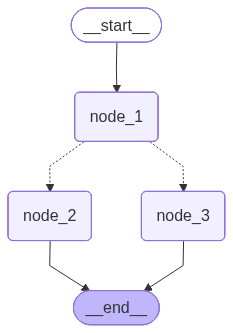

In [10]:
builder = StateGraph(State)

# Add the nodes
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1") # (start, end)
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Compile graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

## Graph invocation

Standard way to invoke a Graph

- `.invoke(<start_state>)`: Method to execute the graph synchronously by providing the initial state
- Each node overrides the current state
- Returns the final nodes state

In [11]:
graph.invoke({"graph_state": "Hi, this is Martin."})

---- Node 1 ----
---- Node 3 ----


{'graph_state': 'Hi, this is Martin. I am Sad!'}

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


---

# Chain

- Chat messages in the graph
- Using chat models
- Binding tools to the LLM
- Executing tool calls in the graph

In [38]:
import os
from pprint import pprint
from dotenv import load_dotenv
from typing import Annotated

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, AnyMessage
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq
load_dotenv()

True

## Messages

Messages capture the different roles within a conversation

- Includes: `HumanMessage`, `AIMessage`, `SystemMessage`, and `ToolMessage`

Each message contains the following details

- `content`: Content of the message
- `name`: Optional, who is creating the message
- `response_metadata`: Optional, details about the chat provided by the model

In [13]:
messages = [AIMessage(
    content="So you said you were researching about ocean mammals?",
    name="Model")
]
messages.extend([HumanMessage(
    content="Yes, that's right",
    name="Martin"
)])
messages.extend([AIMessage(
    content="Great, what would you like to learn about?",
    name="Model"
)])
messages.extend([HumanMessage(
    content="I want to learn about the sea creatures around Singapore",
    name="Martin"
)])

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching about ocean mammals?
================================ Human Message =================================
Name: Martin

Yes, that's right
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about?
================================ Human Message =================================
Name: Martin

I want to learn about the sea creatures around Singapore


In [18]:
# Define the LLM provider
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY", "")
)

result = llm.invoke(messages)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [19]:
result

AIMessage(content="Singapore is a great location to learn about marine life, being a tropical island with a rich coastline. Some popular sea creatures found around Singapore include:\n\n1. **Dugongs**: Although rare and endangered, dugongs can be found in the waters around Singapore. They are large marine mammals that feed on sea grasses.\n2. **Dolphins**: Bottlenose dolphins and other species have been spotted in the waters around Singapore, particularly in areas like Pulau Ubin and the Southern Islands.\n3. **Whales**: Humpback whales, pilot whales, and other species can be seen migrating through the waters around Singapore, particularly during the winter months.\n4. **Sea Turtles**: Green sea turtles, hawksbill sea turtles, and leatherback sea turtles can be found nesting on beaches around Singapore, such as Pulau Ubin and Chek Jawa.\n5. **Manta Rays**: These large, gentle creatures can be seen in the waters around Singapore, particularly during the summer months when they migrate t

In [20]:
print(result.content)

Singapore is a great location to learn about marine life, being a tropical island with a rich coastline. Some popular sea creatures found around Singapore include:

1. **Dugongs**: Although rare and endangered, dugongs can be found in the waters around Singapore. They are large marine mammals that feed on sea grasses.
2. **Dolphins**: Bottlenose dolphins and other species have been spotted in the waters around Singapore, particularly in areas like Pulau Ubin and the Southern Islands.
3. **Whales**: Humpback whales, pilot whales, and other species can be seen migrating through the waters around Singapore, particularly during the winter months.
4. **Sea Turtles**: Green sea turtles, hawksbill sea turtles, and leatherback sea turtles can be found nesting on beaches around Singapore, such as Pulau Ubin and Chek Jawa.
5. **Manta Rays**: These large, gentle creatures can be seen in the waters around Singapore, particularly during the summer months when they migrate to Singapore's waters to f

In [25]:
result.response_metadata

{'token_usage': {'completion_tokens': 456,
  'prompt_tokens': 85,
  'total_tokens': 541,
  'completion_time': 0.636399839,
  'completion_tokens_details': None,
  'prompt_time': 0.005602056,
  'prompt_tokens_details': None,
  'queue_time': 0.156719478,
  'total_time': 0.642001895},
 'model_name': 'llama-3.1-8b-instant',
 'system_fingerprint': 'fp_7ccc667439',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

## Tools

Tools are used to control parts of the code or use external APIs

- `ChatModel.bind_tools()`: To add any Python function

In [32]:
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b together

    Args:
        a (int): Integer 1
        b (int): Integer 2

    Returns:
        int: Multiplication of both integers
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

In [27]:
tool_call = llm_with_tools.invoke([
    HumanMessage(content="What is 2 multipled by 3", name="Martin")
])

tool_call

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'tgyxerad7', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 237, 'total_tokens': 256, 'completion_time': 0.03521418, 'completion_tokens_details': None, 'prompt_time': 0.0552291, 'prompt_tokens_details': None, 'queue_time': 0.120202384, 'total_time': 0.09044328}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e43f4-bdba-71b3-a8df-cfd98c663e8b-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'tgyxerad7', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 237, 'output_tokens': 19, 'total_tokens': 256})

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [28]:
tool_call.additional_kwargs['tool_calls']

[{'id': 'tgyxerad7',
  'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'},
  'type': 'function'}]

## Messages as a graph state

States are overridden when passing through the graph. So require a _reducer_ function to continuously append messages

- If no reducer function is explicitly stated, the keys are all overidden
- `MessageState` is the pre-built type specified by Langgraph
    - Single `messages` key
    - Contains a list of `AnyMessage` object and a reducer function `add_messages`

In [33]:
# What does the MessageState look like
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# To call it
class State(MessagesState):
    pass

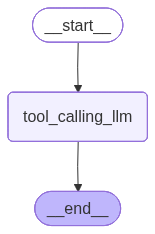

In [37]:
# Creating a graph

# State
class MessagesState(MessagesState):
    pass

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state['messages'])]}

# Graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

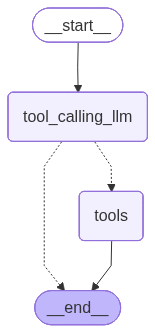

In [39]:
# Extending with tool as a node
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))

builder.add_edge(START, "tool_calling_llm")
# If the latest message (result) is a tool call -> tools_condition routes to tools
# If the latest message (result) is not a tool call -> tools_condition routes to END
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
messages = [HumanMessage(content="Multiply 4 and 5", name="Martin")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================
Name: Martin

Multiply 4 and 5
================================== Ai Message ==================================
Tool Calls:
  multiply (ka482seaa)
 Call ID: ka482seaa
  Args:
    a: 4
    b: 5
================================= Tool Message =================================
Name: multiply

20


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


---

# Agents

Transform the tool calling graph into a __ReAct__ agent architecture

- `act`: lets the model call specific tools
- `observe`: pass the tool output back to the model
- `reason`: Let's the model reason about the tool output and decide what to do next

In [ ]:
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import tools_condition, ToolNode

In [42]:
# Create 4 math tools
def multiply(a: int, b: int) -> int:
    """
    Multiply integers a and b together

    Args:
        a (int): Integer 1
        b (int): Integer 2

    Returns:
        int: Multiplication result of a and b
    """
    return a * b

def add(a: int, b: int) -> int:
    """
    Adds integers a and b together

    Args:
        a (int): Integer 1
        b (int): Integer 2

    Returns:
        int: Addition result of a and b
    """
    return a + b

def subtract(a: int, b: int) -> int:
    """
    Subtracts integer a from integer b

    Args:
        a (int): Integer 1
        b (int): Integer 2

    Returns:
        int: Subtraction result of a and b
    """
    return a - b

def divide(a: int, b: int) -> float:
    """
    Divides integer a and integer b

    Args:
        a (int): Integer 1
        b (int): Integer 2

    Returns:
        int: Division result of a and b
    """
    return a / b

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY", "")
)
llm_with_tools = llm.bind_tools([add, subtract, multiply, divide])

In [43]:
# System message
sys_msg = SystemMessage(
    content="You are a helpful assistant tasked with performing arithmetic on some inputs."
)

# Node
def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

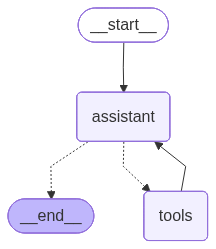

In [45]:
# Build Graph
builder = StateGraph(MessagesState)

# Define the nodes in the graph
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode([divide, multiply, add, subtract]))

# Define the edges
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

graph = builder.compile()

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [50]:
messages = [
    HumanMessage("Add 3 and 4. Multiply the output by 2. Divide the output by 5")
]
result = graph.invoke({"messages": messages})

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [51]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4. Multiply the output by 2. Divide the output by 5
================================== Ai Message ==================================
Tool Calls:
  add (zsmwadwpc)
 Call ID: zsmwadwpc
  Args:
    a: 3
    b: 4
  multiply (mxd7t7dpp)
 Call ID: mxd7t7dpp
  Args:
    a: 7
    b: 2
  divide (we4fxvvsw)
 Call ID: we4fxvvsw
  Args:
    a: 14
    b: 5
================================= Tool Message =================================
Name: add

7
================================= Tool Message =================================
Name: multiply

14
================================= Tool Message =================================
Name: divide

2.8
================================== Ai Message ==================================

The output of the operations is 7, 14, and 2.8.


## Memory

By default all single graph executions are __transient__. We use __persistence__ in the form of memory to address this.

- `MemorySaver()`: An in-memory key-value store for Graph state

Memory requires specification of a `thread_id`, which stores the collection of graph states

![memory](./assets/memory.png)

In [52]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
mem_graph = builder.compile(checkpointer=memory)

In [53]:
# First invocation - Specify thread_id
config = {"configurable": {"thread_id": "1"}}

messages = [HumanMessage("Add 3 and 4")]

result = mem_graph.invoke({"messages": messages}, config)
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4
================================== Ai Message ==================================
Tool Calls:
  add (9y5j5pxsk)
 Call ID: 9y5j5pxsk
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

To get the answer, we need to call the divide function with a result of 7 and a divisor of 1.


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [54]:
# Second invocation
messages = [HumanMessage("Multiple that by 3")]

result = mem_graph.invoke({"messages": messages}, config)
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4
================================== Ai Message ==================================
Tool Calls:
  add (9y5j5pxsk)
 Call ID: 9y5j5pxsk
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

To get the answer, we need to call the divide function with a result of 7 and a divisor of 1.
================================ Human Message =================================

Multiple that by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (a9044yq8h)
 Call ID: a9044yq8h
  Args:
    a: 7
    b: 3
================================= Tool Message =================================
Name: multiply

21
================================== Ai Message ==================================

To get the answer, we need to call

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [ ]:
%load_ext watermark
%watermark